## Exp 1: Developing a Neural Network Regression Model
## Name: Manikumar dk 
## Reg No: 212223230121

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [19]:
dataset1 = pd.read_csv('/content/drive/MyDrive/deep learning/experiment 1 - Sheet1 (2).csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [24]:
print(X)
print(y)

[[ 6]
 [ 5]
 [ 3]
 [ 7]
 [ 8]
 [ 5]
 [ 2]
 [21]
 [ 6]
 [76]
 [43]
 [12]
 [35]
 [65]]
[[ 78]
 [  7]
 [  8]
 [ 65]
 [465]
 [ 78]
 [ 89]
 [ 65]
 [ 78]
 [ 98]
 [ 34]
 [ 23]
 [ 41]
 [ 91]]


In [28]:
dataset1.head()

,Input,Output
0,6,78
1,5,7
2,3,8
3,7,65
4,8,465


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [21]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [30]:
# Name:Manikumar dk
# Register Number:212223230121
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}

  def forward(self,x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3(x)
    return x






In [31]:
# Initialize the Model, Loss Function, and Optimizer
ai_brain = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(ai_brain.parameters(), lr=0.001)#lr=learning rate

In [32]:
# Name:Manikumar dk
# Register Number:212223230121
def train_model(ai_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss=criterion(ai_brain(X_train),y_train)
        loss.backward()
        optimizer.step()


        ai_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [34]:
train_model(ai_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 16900.792969
Epoch [200/2000], Loss: 16849.757812
Epoch [400/2000], Loss: 16820.142578
Epoch [600/2000], Loss: 16805.599609
Epoch [800/2000], Loss: 16800.177734
Epoch [1000/2000], Loss: 16797.650391
Epoch [1200/2000], Loss: 16796.544922
Epoch [1400/2000], Loss: 16796.126953
Epoch [1600/2000], Loss: 16795.990234
Epoch [1800/2000], Loss: 16795.945312


In [35]:
with torch.no_grad():
    test_loss = criterion(ai_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 4615.577637


In [36]:
loss_df = pd.DataFrame(ai_brain.history)

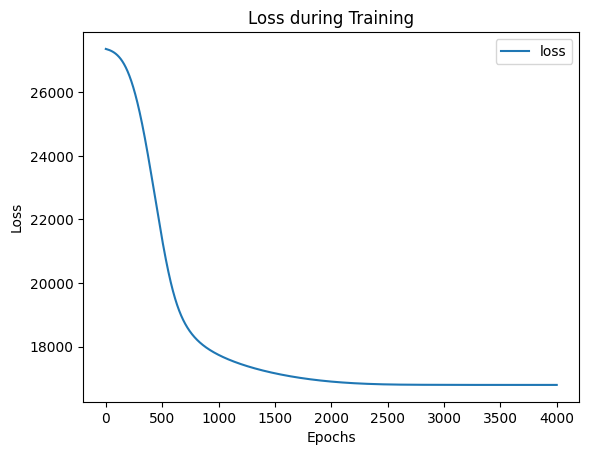

In [37]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [38]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = ai_brain(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 105.73706817626953
